In [53]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists as fl

In [54]:
df=pd.read_csv('../../../data/processed/major_leagues/EWMA_Major_Leagues.csv')

In [55]:
df=df[df['position']=='Defenders']

In [56]:
df=df.drop(columns=fl.goalkeeper_features_z)

In [57]:
df=df.drop(columns=[
    'rating_zscore',
    'countrating_zscore',
    'totalrating_zscore',
])

In [58]:
existing_cols_to_drop = [col for col in fl.volume_zscore_cols if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

In [59]:
df.shape

(1723, 100)

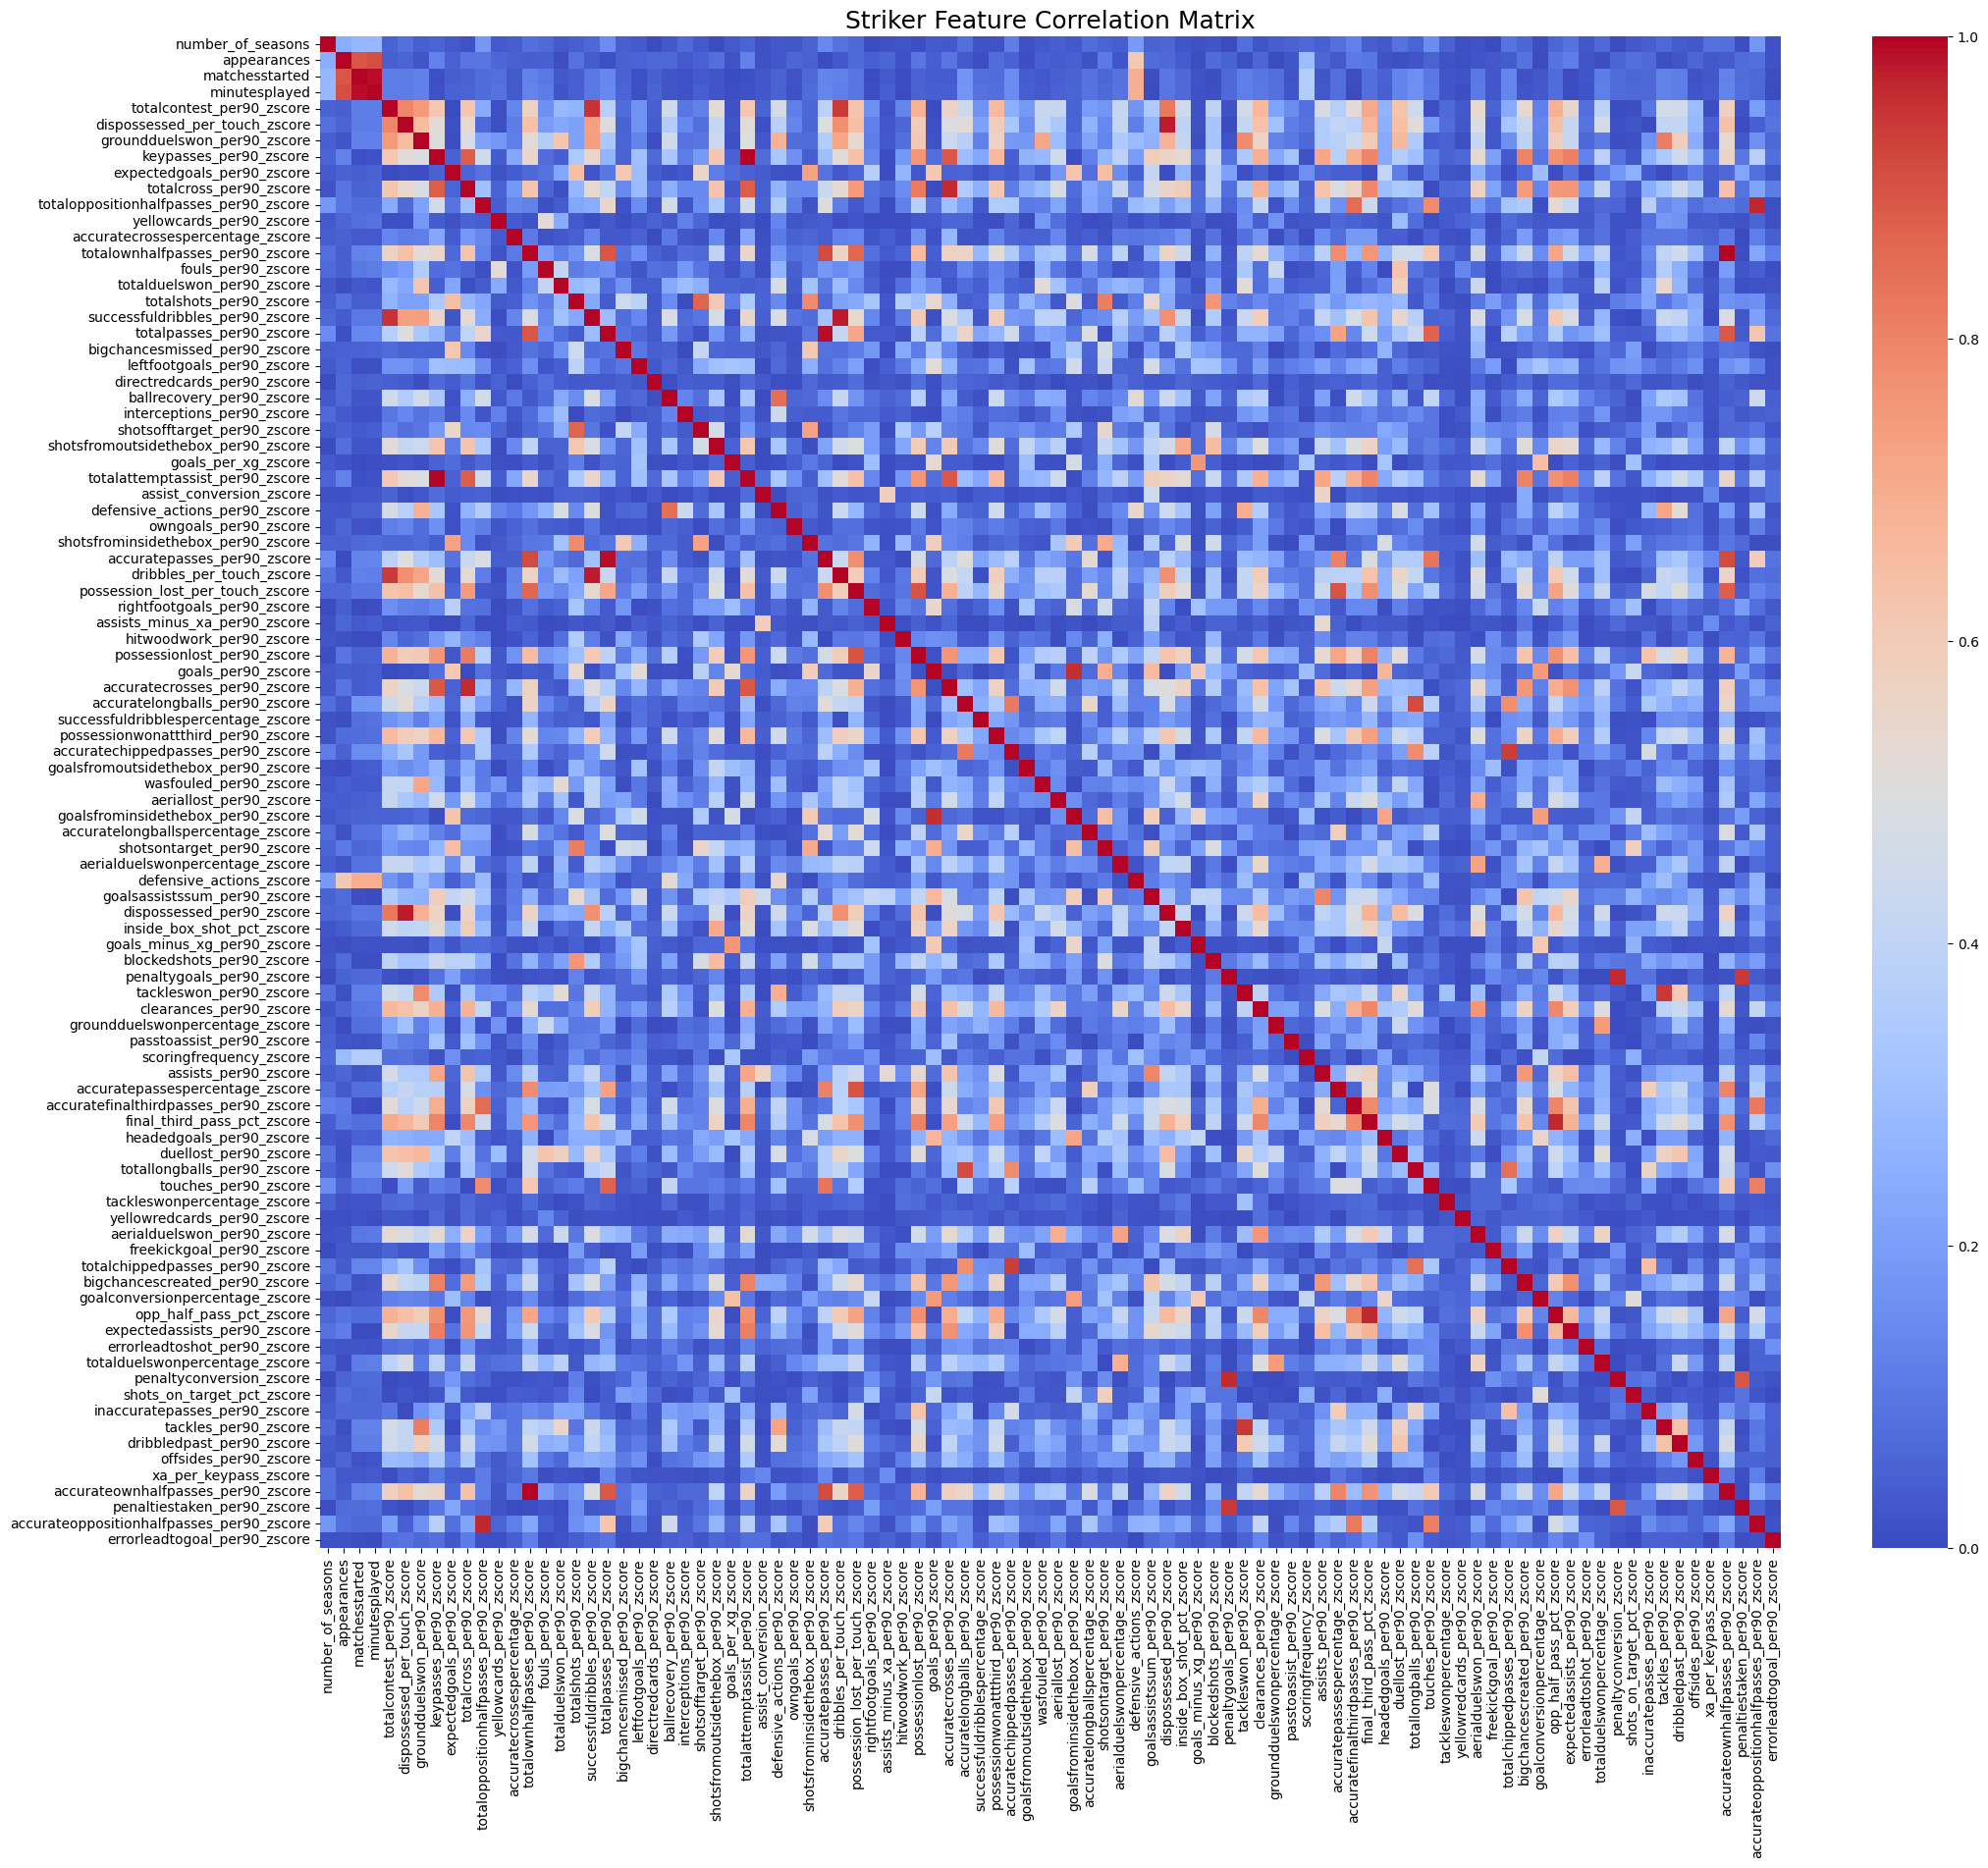

In [60]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [61]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,keypasses_per90_zscore,totalattemptassist_per90_zscore,0.999365
1,totalownhalfpasses_per90_zscore,accurateownhalfpasses_per90_zscore,0.998480
2,totalpasses_per90_zscore,accuratepasses_per90_zscore,0.991134
3,matchesstarted,minutesplayed,0.988397
4,successfuldribbles_per90_zscore,dribbles_per_touch_zscore,0.978478
5,dispossessed_per_touch_zscore,dispossessed_per90_zscore,0.977283
6,totaloppositionhalfpasses_per90_zscore,accurateoppositionhalfpasses_per90_zscore,0.966248
7,final_third_pass_pct_zscore,opp_half_pass_pct_zscore,0.964906
8,penaltygoals_per90_zscore,penaltyconversion_zscore,0.963241
9,totalcross_per90_zscore,accuratecrosses_per90_zscore,0.962397


In [62]:
df=df.drop(columns=[
    'totalattemptassist_per90_zscore','totalownhalfpasses_per90_zscore',
    'totalpasses_per90_zscore','dispossessed_per90_zscore','penaltygoals_per90_zscore',
    'accuratechippedpasses_per90_zscore','totallongballs_per90_zscore','totalchippedpasses_per90_zscore',
    'totalcross_per90_zscore','penaltyconversion_zscore','penaltiestaken_per90_zscore','accurateownhalfpasses_per90_zscore',
    'defensive_actions_per90_zscore','goalsfrominsidethebox_per90_zscore','dribbles_per_touch_zscore',
    'totalcontest_per90_zscore','opp_half_pass_pct_zscore','totaloppositionhalfpasses_per90_zscore',
    'tackles_per90_zscore','possessionlost_per90_zscore','totalshots_per90_zscore','accuratecrosses_per90_zscore',
    'accuratepassespercentage_zscore'
    ])

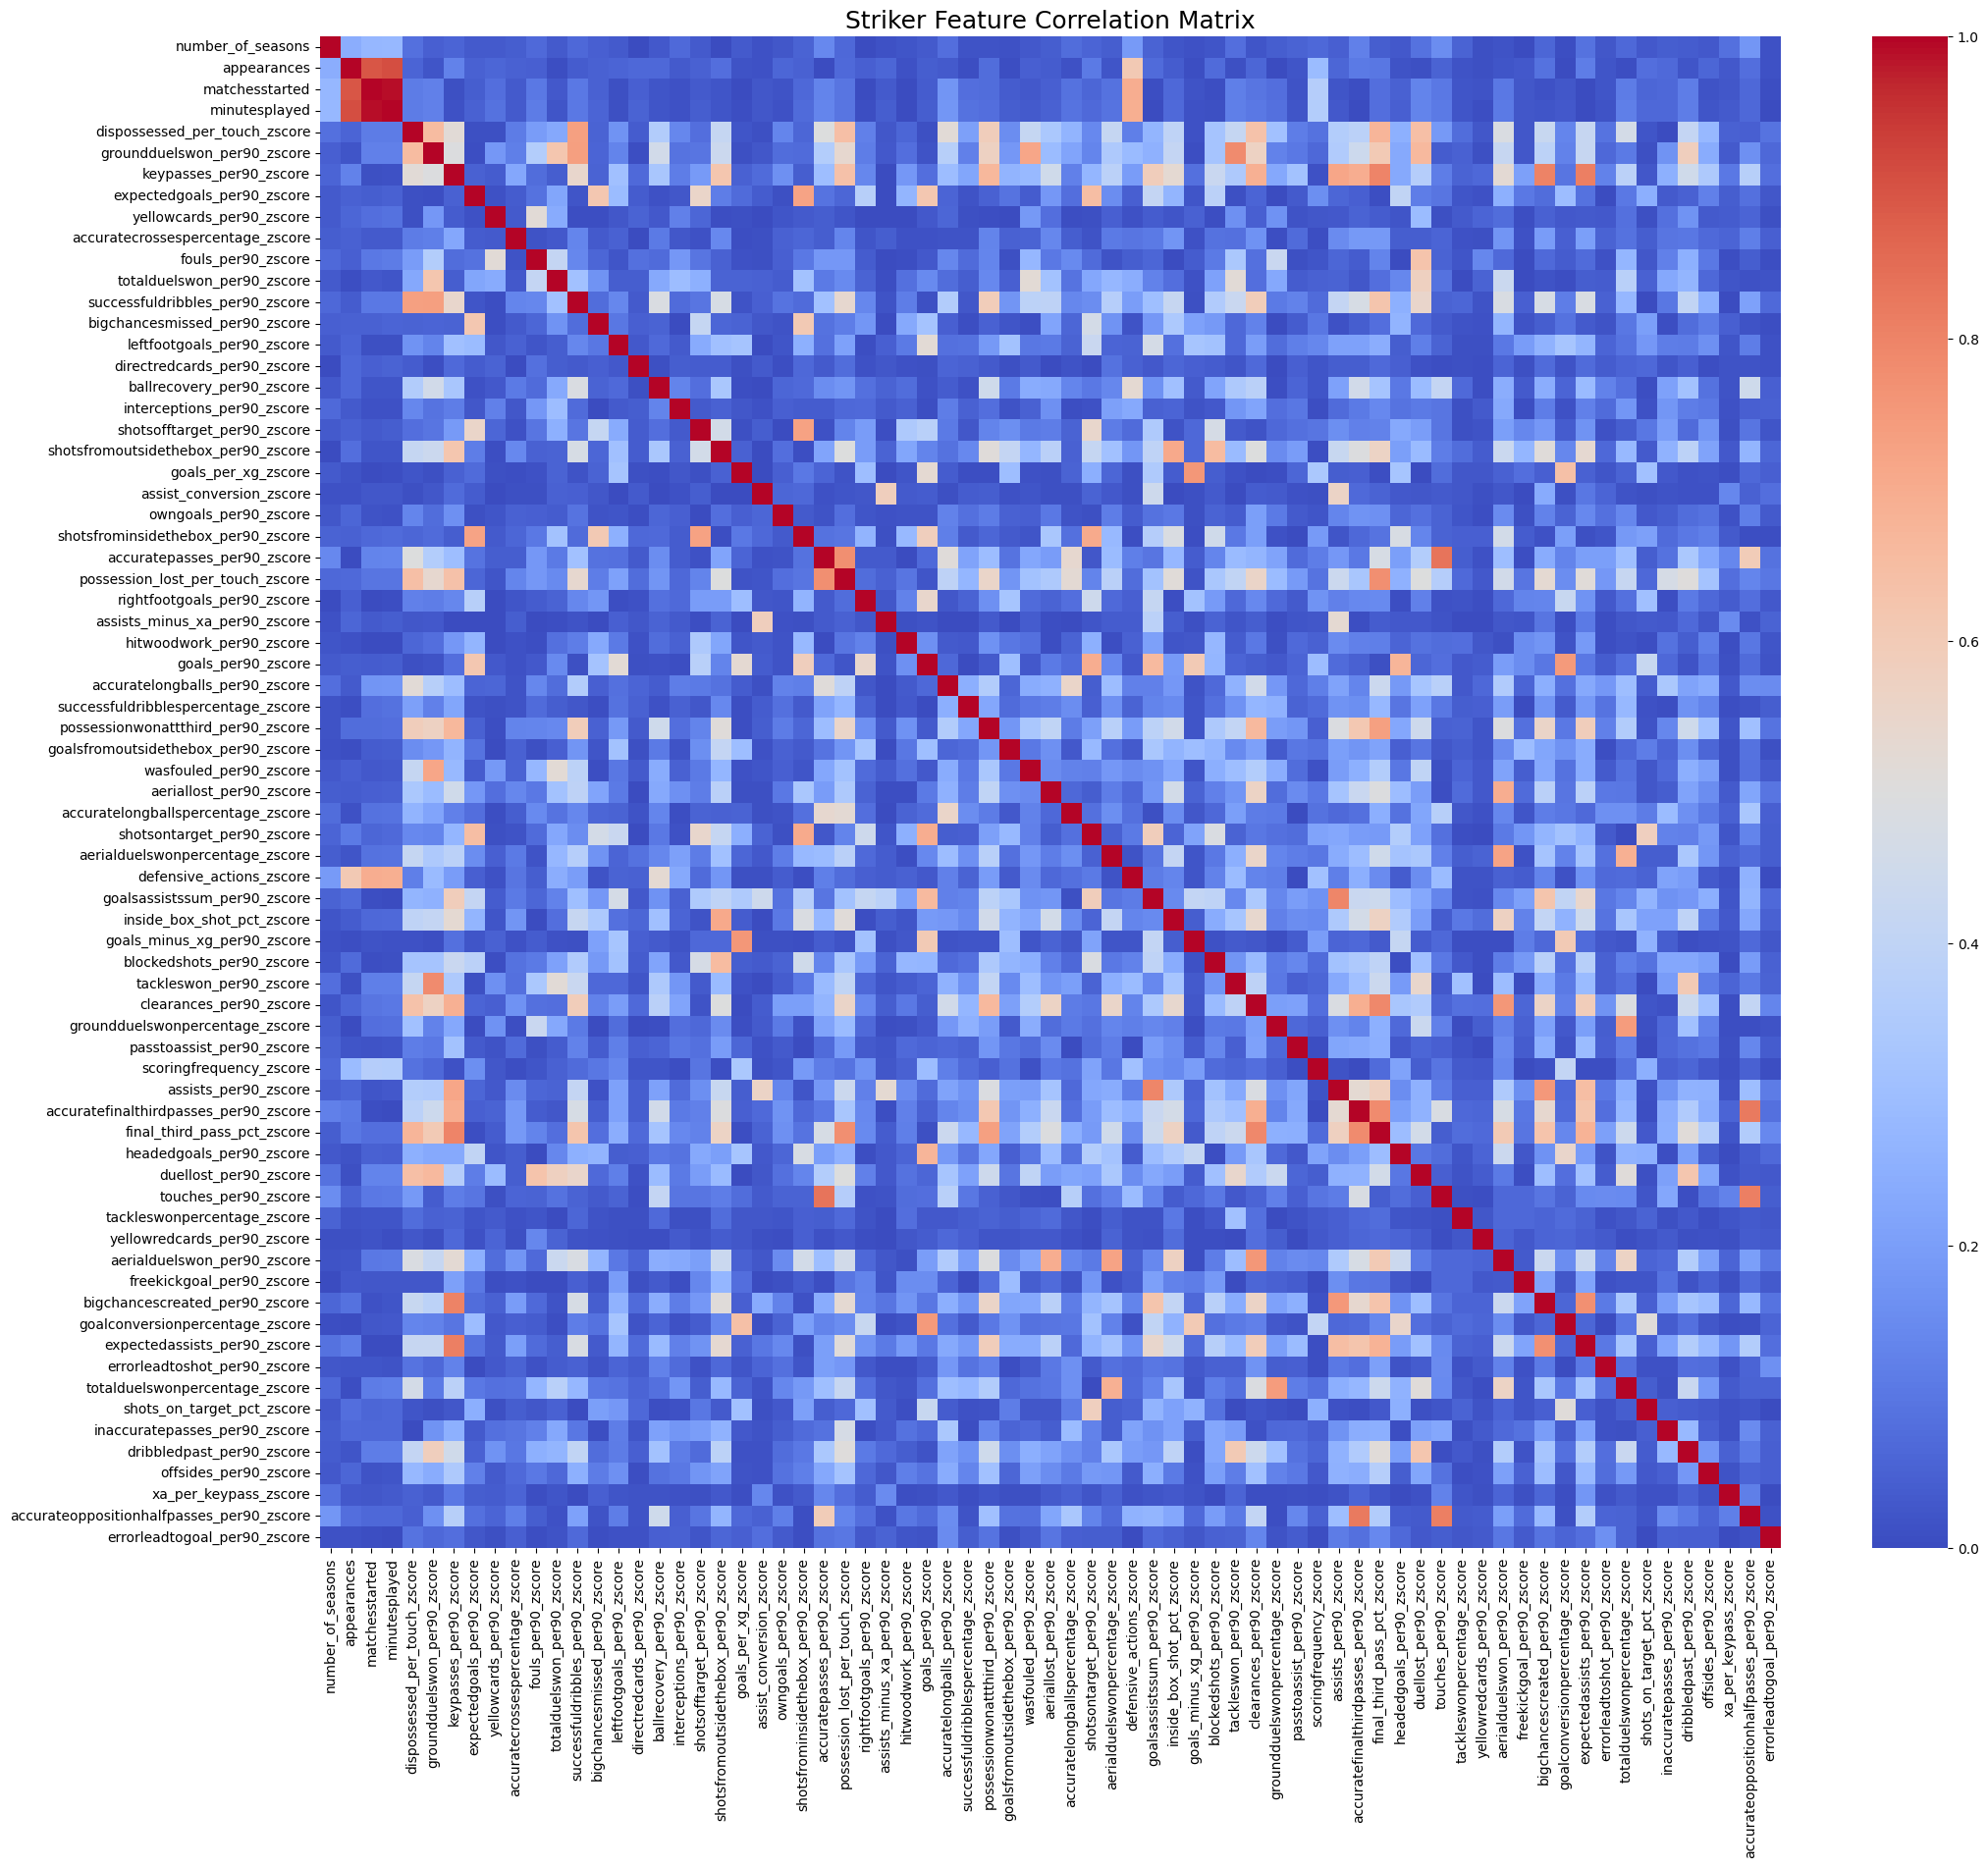

In [63]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [64]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,matchesstarted,minutesplayed,0.988397
1,appearances,minutesplayed,0.907574
2,appearances,matchesstarted,0.891289
3,accuratepasses_per90_zscore,touches_per90_zscore,0.834383
4,accuratefinalthirdpasses_per90_zscore,accurateoppositionhalfpasses_per90_zscore,0.823070
5,keypasses_per90_zscore,expectedassists_per90_zscore,0.811714
6,touches_per90_zscore,accurateoppositionhalfpasses_per90_zscore,0.809415
7,keypasses_per90_zscore,bigchancescreated_per90_zscore,0.804132


In [65]:
df.shape

(1723, 77)

In [66]:
df.columns.to_list()

['player id',
 'player',
 'team id',
 'team',
 'league',
 'position',
 'number_of_seasons',
 'appearances',
 'matchesstarted',
 'minutesplayed',
 'dispossessed_per_touch_zscore',
 'groundduelswon_per90_zscore',
 'keypasses_per90_zscore',
 'expectedgoals_per90_zscore',
 'yellowcards_per90_zscore',
 'accuratecrossespercentage_zscore',
 'fouls_per90_zscore',
 'totalduelswon_per90_zscore',
 'successfuldribbles_per90_zscore',
 'bigchancesmissed_per90_zscore',
 'leftfootgoals_per90_zscore',
 'directredcards_per90_zscore',
 'ballrecovery_per90_zscore',
 'interceptions_per90_zscore',
 'shotsofftarget_per90_zscore',
 'shotsfromoutsidethebox_per90_zscore',
 'goals_per_xg_zscore',
 'assist_conversion_zscore',
 'owngoals_per90_zscore',
 'shotsfrominsidethebox_per90_zscore',
 'accuratepasses_per90_zscore',
 'possession_lost_per_touch_zscore',
 'rightfootgoals_per90_zscore',
 'assists_minus_xa_per90_zscore',
 'hitwoodwork_per90_zscore',
 'goals_per90_zscore',
 'accuratelongballs_per90_zscore',
 'suc

In [67]:
df.to_csv('../../../data/processed/major_leagues/Defenders/EWMA_Major_Defenders.csv',index=False)